# AeroNet Lite — Drone Anomaly Classification

This notebook trains a classifier for drone flight anomalies using synthetic telemetry.

Synthetic anomaly data is acceptable here because the project brief allows synthetic anomaly labels when the logic is clearly explained.  
The labels are generated from realistic rule patterns:

- **Normal**
- **Battery anomaly**
- **Route anomaly**
- **Sensor spike**

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

## 1. Generate Synthetic Drone Telemetry

Features:

- `battery_drop`: battery percentage drop in a short interval
- `speed`: drone speed
- `route_deviation`: distance away from planned route
- `altitude_change`: sudden altitude jump/drop

In [7]:
def make_synthetic_anomaly_data(n=900, seed=12):
    rng = np.random.default_rng(seed)

    labels = rng.choice(
        ["Normal", "Battery anomaly", "Route anomaly", "Sensor spike"],
        size=n,
        p=[0.58, 0.16, 0.16, 0.10],
    )

    rows = []

    for label in labels:
        if label == "Normal":
            battery_drop = rng.normal(3.0, 0.9)
            speed = rng.normal(8.0, 1.2)
            route_deviation = rng.normal(0.4, 0.25)
            altitude_change = rng.normal(1.2, 0.8)

        elif label == "Battery anomaly":
            battery_drop = rng.normal(13.0, 2.2)
            speed = rng.normal(7.5, 1.4)
            route_deviation = rng.normal(0.7, 0.3)
            altitude_change = rng.normal(1.5, 1.0)

        elif label == "Route anomaly":
            battery_drop = rng.normal(4.5, 1.2)
            speed = rng.normal(8.5, 1.5)
            route_deviation = rng.normal(4.0, 0.9)
            altitude_change = rng.normal(2.0, 1.0)

        else:
            battery_drop = rng.normal(5.0, 1.5)
            speed = rng.normal(16.0, 2.6)
            route_deviation = rng.normal(1.1, 0.5)
            altitude_change = rng.normal(8.0, 2.4)

        rows.append({
            "battery_drop": max(0, battery_drop),
            "speed": max(0, speed),
            "route_deviation": max(0, route_deviation),
            "altitude_change": max(0, altitude_change),
            "label": label,
        })

    return pd.DataFrame(rows).round(3)


df = make_synthetic_anomaly_data()
print(df.shape)
df.head()

(900, 5)


,battery_drop,speed,route_deviation,altitude_change,label
0,3.347,7.659,0.471,1.684,Normal
1,3.922,16.641,0.893,11.496,Sensor spike
2,2.594,8.146,0.025,0.110,Normal
3,2.920,6.905,0.327,1.388,Normal
4,3.505,6.312,0.354,1.730,Normal


## 2. Class Distribution

In [8]:
class_counts = df["label"].value_counts()
class_counts

label
Normal             518
Route anomaly      162
Battery anomaly    122
Sensor spike        98
Name: count, dtype: int64

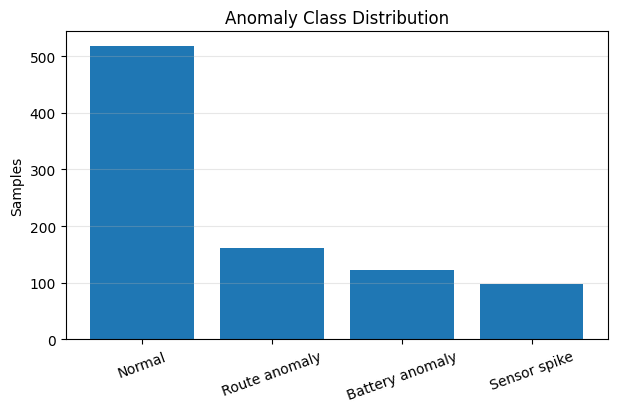

In [9]:
plt.figure(figsize=(7, 4))
plt.bar(class_counts.index, class_counts.values)
plt.ylabel("Samples")
plt.title("Anomaly Class Distribution")
plt.xticks(rotation=20)
plt.grid(True, axis="y", alpha=0.3)
plt.show()

## 3. Train Classifiers

In [10]:
feature_names = ["battery_drop", "speed", "route_deviation", "altitude_change"]

X = df[feature_names]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=12,
    stratify=y,
)

models = {
    "Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=12),
    "Random Forest": RandomForestClassifier(n_estimators=120, max_depth=7, random_state=12),
}

results = []
trained_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    acc = accuracy_score(y_test, pred)
    results.append({"model": name, "accuracy": round(acc, 3)})
    trained_models[name] = model

results_df = pd.DataFrame(results).sort_values("accuracy", ascending=False)
results_df

,model,accuracy
1,Random Forest,1.000
0,Decision Tree,0.996


## 4. Confusion Matrix and Classification Report

In [11]:
best_model_name = results_df.iloc[0]["model"]
best_model = trained_models[best_model_name]
y_pred = best_model.predict(X_test)

labels = ["Normal", "Battery anomaly", "Route anomaly", "Sensor spike"]
cm = confusion_matrix(y_test, y_pred, labels=labels)

print("Best model:", best_model_name)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, labels=labels))

cm_df = pd.DataFrame(cm, index=labels, columns=labels)
cm_df

Best model: Random Forest

Classification Report:
                 precision    recall  f1-score   support

         Normal       1.00      1.00      1.00       129
Battery anomaly       1.00      1.00      1.00        30
  Route anomaly       1.00      1.00      1.00        41
   Sensor spike       1.00      1.00      1.00        25

       accuracy                           1.00       225
      macro avg       1.00      1.00      1.00       225
   weighted avg       1.00      1.00      1.00       225



,Normal,Battery anomaly,Route anomaly,Sensor spike
Normal,129,0,0,0
Battery anomaly,0,30,0,0
Route anomaly,0,0,41,0
Sensor spike,0,0,0,25


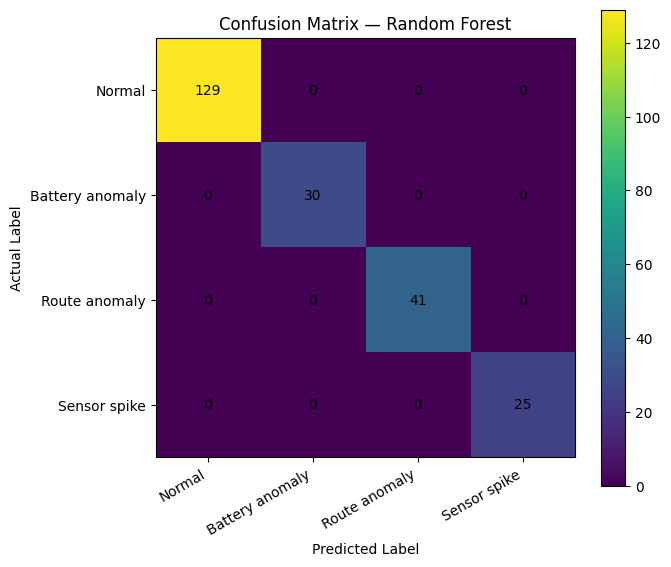

In [12]:
plt.figure(figsize=(7, 6))
plt.imshow(cm)
plt.title(f"Confusion Matrix — {best_model_name}")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.xticks(range(len(labels)), labels, rotation=30, ha="right")
plt.yticks(range(len(labels)), labels)
plt.colorbar()

for i in range(len(labels)):
    for j in range(len(labels)):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()

## 5. Feature Importance

In [13]:
if hasattr(best_model, "feature_importances_"):
    importance_df = pd.DataFrame({
        "feature": feature_names,
        "importance": best_model.feature_importances_,
    }).sort_values("importance", ascending=False)
else:
    importance_df = pd.DataFrame({
        "feature": feature_names,
        "importance": np.abs(best_model.feature_importances_),
    }).sort_values("importance", ascending=False)

importance_df

,feature,importance
2,route_deviation,0.387752
0,battery_drop,0.348653
3,altitude_change,0.163444
1,speed,0.100150


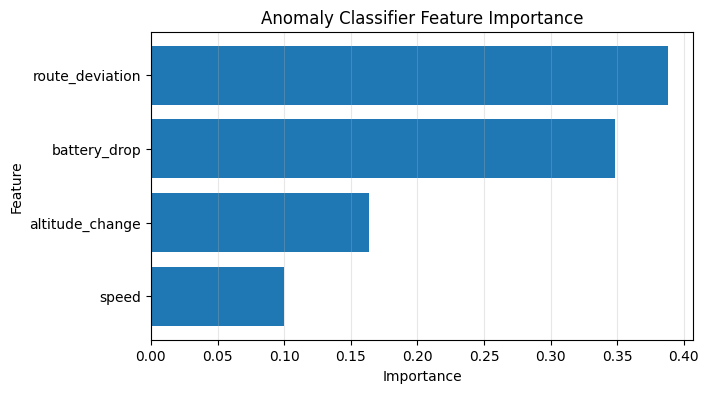

In [14]:
plt.figure(figsize=(7, 4))
plt.barh(importance_df["feature"], importance_df["importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Anomaly Classifier Feature Importance")
plt.gca().invert_yaxis()
plt.grid(True, axis="x", alpha=0.3)
plt.show()

## 6. Test Custom Drone Telemetry

In [15]:
def predict_custom_anomaly(battery_drop, speed, route_deviation, altitude_change):
    sample = pd.DataFrame([{
        "battery_drop": battery_drop,
        "speed": speed,
        "route_deviation": route_deviation,
        "altitude_change": altitude_change,
    }])
    return best_model.predict(sample)[0]


test_cases = pd.DataFrame([
    {"battery_drop": 2.5, "speed": 8.0, "route_deviation": 0.3, "altitude_change": 1.0},
    {"battery_drop": 15.0, "speed": 7.5, "route_deviation": 0.6, "altitude_change": 1.5},
    {"battery_drop": 4.0, "speed": 8.4, "route_deviation": 4.5, "altitude_change": 2.0},
    {"battery_drop": 5.0, "speed": 18.0, "route_deviation": 1.0, "altitude_change": 9.0},
])

test_cases["predicted_label"] = [
    predict_custom_anomaly(**row.to_dict())
    for _, row in test_cases.iterrows()
]

test_cases

,battery_drop,speed,route_deviation,altitude_change,predicted_label
0,2.5,8.0,0.3,1.0,Normal
1,15.0,7.5,0.6,1.5,Battery anomaly
2,4.0,8.4,4.5,2.0,Route anomaly
3,5.0,18.0,1.0,9.0,Sensor spike
